In [2]:
from ToyMaker import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Constants
n1 = 3.5
n2 = 3.5
k1 = 4400 
k2 = 8080
γr1 = 1/5
γr2 = 50/251
β1 = 216/125
β2 = 216/125
kp1 = 50 
kp2 = 45
γp1 = 1/45
γp2 = 1/45

# Species
def p1(p1): return p1
def p2(p2): return p2

# Propensities
def s1 (p2) : return β1 * ((p2**n1) / (k1**n1 + p2**n1))
def s2 (r1) : return γr1 * r1
def s3 (p1) : return β2/(1 + (p1/k2)**n2)
def s4 (r2) : return γr2 * r2
def s5 (r1) : return kp1 * r1
def s6 (p1) : return γp1 * p1
def s7 (r2) : return kp2 * r2
def s8 (p2) : return γp2 * p2

# Species
species = {
            't':    0., 
            'cell': 0, 
            p1:   0., 
            p2:   0., 
            'r1':   0., 
            'r2':   0.}

reactions = {
            s1: {'create':    ['r1']},
            s2: {'destroy':   ['r1']},
            s3: {'create':    ['r2']},
            s4: {'destroy':   ['r2']},
            s5: {'create':    ['p1']},
            s6: {'destroy':   ['p1']},
            s7: {'create':    ['p2']},
            s8: {'destroy':   ['p2']}
}

tmax = 700
sampling_time = 1
samples = 10

In [3]:
# multiple_cells_by_batch(species, reactions, tmax, sampling_time, samples=1, batch_size=10)

In [4]:
# cells = multiple_Cells(species, reactions, tmax, sampling_time, cells=1);

In [5]:
# [plt.plot(cells[i][:, 0], cells[i][:, 2]) for i in range(samples)];
# [plt.plot(cells[i][:, 0], cells[0][:, 3]) for i in range(samples)];

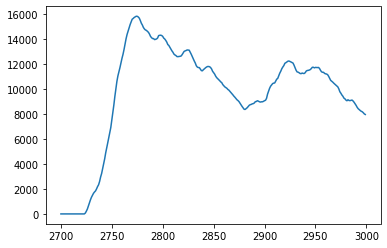

In [6]:
df = pd.read_csv('Toy_model.csv')
# [plt.plot(df['t'][df['cell'] == i], df['p2'][df['cell'] == i], '-', ms=0.5) for i in range(10)];
# [plt.plot(df['t'][df['cell'] == i], df['p1'][df['cell'] == i], '-', ms=0.5) for i in range(10)];
plt.plot(df['p1'][df['cell'] == 10])

# plt.yscale('log')

In [7]:
# Parameters

gamma_r = 1/5
gamma_p = 1/20
gamma_z = 1/20

kz = 3.2 * gamma_p
kr = 1
kp = 50

def γr(r): return gamma_r * r
def γp(p) : return gamma_p * p
def γz(z) : return gamma_z * z

def k_z() : return 3.2 * gamma_p
def k_r(z) : return kr * z * (gamma_z/kz)
def k_p(r) : return kp * r

In [8]:
kr*kp/(gamma_z*gamma_r)

4999.999999999999

In [9]:
%%time
species = {
            't':    0., 
            'cell': 0,
            'z': 0.,
            'r': 0.,
            'p': 0.,            
            }

reactions = {
            k_z: {'create':    ['z']},
            k_r: {'create':    ['r']},
            k_p: {'create':    ['p']},
            γz : {'destroy':   ['z']},
            γr : {'destroy':   ['r']},
            γp : {'destroy':   ['p']},
}


tmax = 10
sampling_time = 1
samples = 1

# cells_2 = multiple_Cells(species, reactions, tmax, sampling_time, cells=samples);


CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 33.6 µs


In [10]:
%%time
multiple_cells_by_batch(species, reactions, tmax, sampling_time, samples=samples, batch_size=30, file_name='Tactic_model')

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 234 ms, sys: 31.2 ms, total: 266 ms
Wall time: 274 ms


[[<matplotlib.lines.Line2D at 0x7fd95b028e50>],

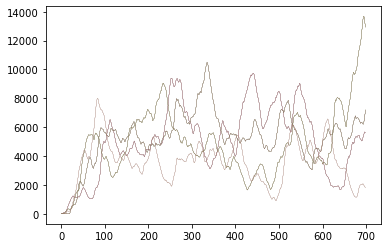

In [ ]:
%%time
cells_2 = pd.read_csv('Tactic_model.csv')
samples = 30
# [plt.plot(cells_2['t'][cells_2['cell'] == i], cells_2['z'][cells_2['cell'] == i], '-', ms=0.5, color='blue') for i in range(samples)];
# [plt.plot(cells_2['t'][cells_2['cell'] == i], cells_2['r'][cells_2['cell'] == i], '-', ms=0.5, color='red') for i in range(samples)];
[plt.plot(cells_2['t'][cells_2['cell'] == 1], cells_2['p'][cells_2['cell'] == i], '-', ms=0.5, lw=0.1) for i in range(1, samples)];

In [ ]:
# fig, ax = plt.subplots(figsize=(10,5))
# multiple_Cells_1 = [Cell(species, reactions, tmax, sampling_time, cell=c, deterministic=False) for c in tqdm(range(1, 10+1))];

In [ ]:
# fig, ax = plt.subplots(figsize=(20,10))
# [plt.plot(multiple_Cells_1[c][:, 0], multiple_Cells_1[c][:, 2], lw=1) for c in range(samples)];